<a href="https://colab.research.google.com/github/lalasa043/Customer-Churn-Prediction-ML/blob/main/Building_Convolutional_Neural_Networks_on_MNIST_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1.1: Data Loading and Exploration

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Test labels shape: (10000,)


Task 1.2: Data Pre-processing (follow this step as I explain in CNN
Demonstration )


1.Normalization

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

2.Reshaping

In [ ]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


One-Hot Encode Labels

In [ ]:
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)


3. Data Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rotation_range=10,zoom_range=0.1,width_shift_range=0.1,height_shift_range=0.1)
datagen.fit(X_train)

Part 2: Building Basic CNN Architecture


Task 2.1: Design CNN Architecture: Build a CNN with the following
specifications:

Model Architecture:

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,162 (1004.54 KB)

 Trainable params: 257,162 (1004.54 KB)

 Non-trainable params: 0 (0.00 B)

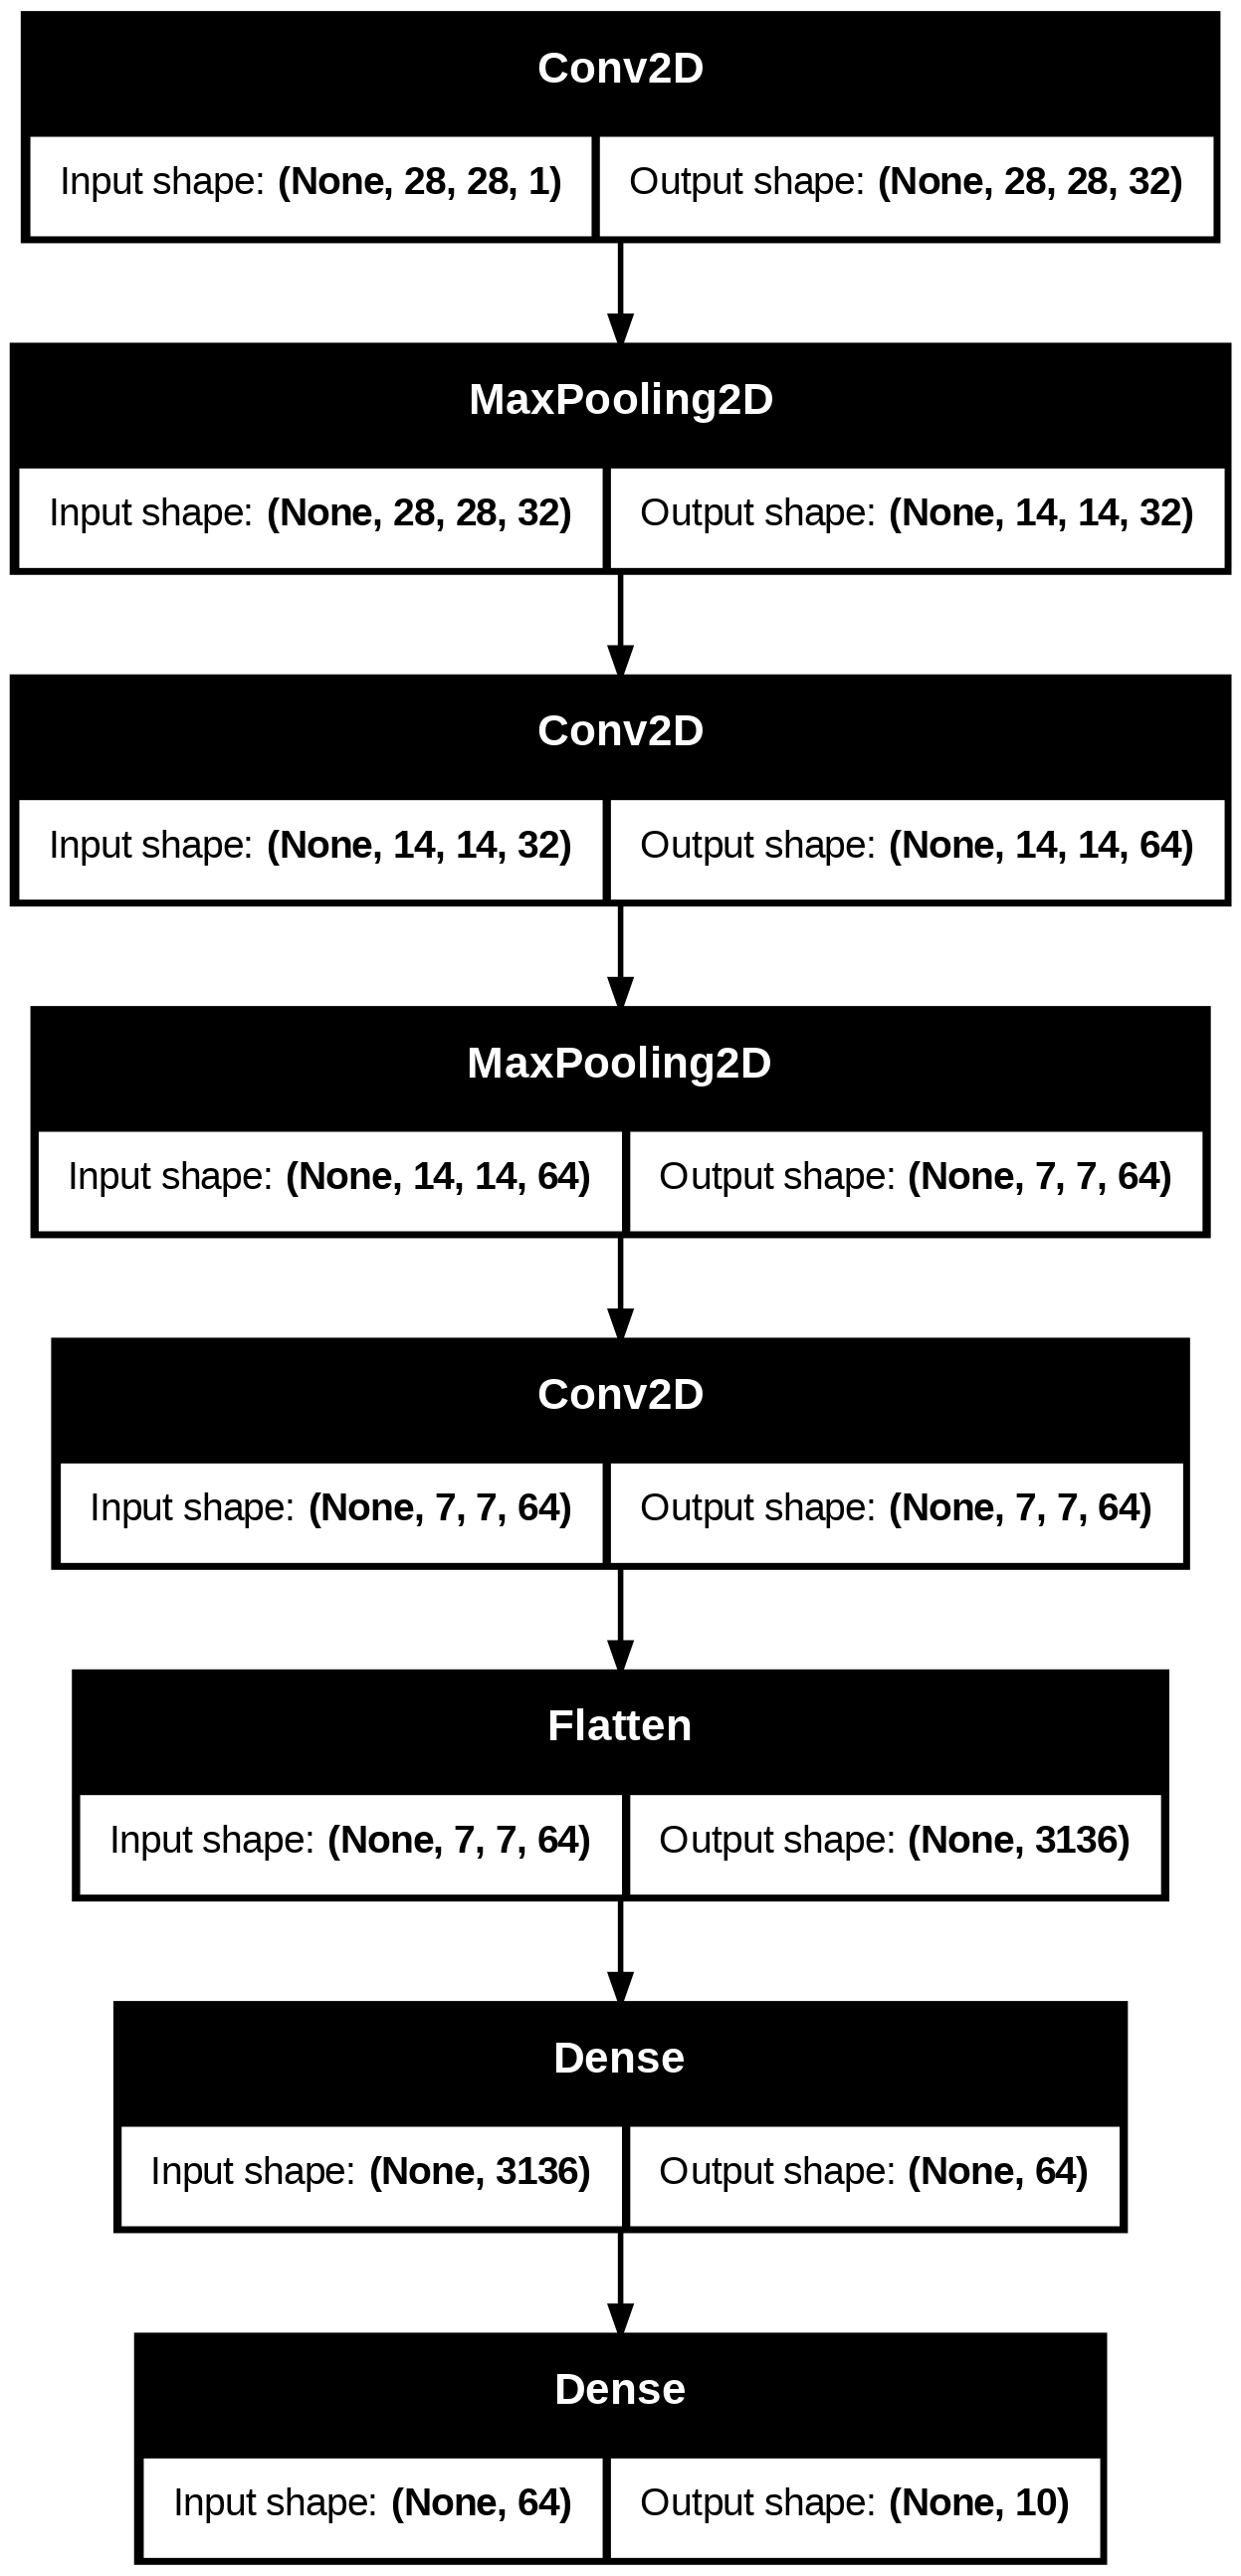

In [ ]:
keras.utils.plot_model(model, show_shapes=True)


In [ ]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])


Requirements

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models


In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Task 2.2: Model Compilation

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])


Part 3: Model Training and Evaluation

Task 3.1: Training Setup

1.Training Configuration:

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1)


Epoch 1/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - accuracy: 0.8078 - loss: 0.6477 - val_accuracy: 0.9693 - val_loss: 0.1064
Epoch 2/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 49s 202ms/step - accuracy: 0.9745 - loss: 0.0842 - val_accuracy: 0.9827 - val_loss: 0.0661
Epoch 3/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 33s 138ms/step - accuracy: 0.9854 - loss: 0.0483 - val_accuracy: 0.9802 - val_loss: 0.0651
Epoch 4/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 34s 140ms/step - accuracy: 0.9888 - loss: 0.0375 - val_accuracy: 0.9863 - val_loss: 0.0530
Epoch 5/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 41s 139ms/step - accuracy: 0.9913 - loss: 0.0259 - val_accuracy: 0.9859 - val_loss: 0.0551
Epoch 6/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 41s 139ms/step - accuracy: 0.9943 - loss: 0.0174 - val_accuracy: 0.9879 - val_loss: 0.0437
Epoch 7/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 41s 140ms/step - accuracy: 0.9964 - loss: 0.0132 - val_accuracy: 0.9858 - val_loss: 0.0529
Epoch 8/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 33s 137ms/step - accuracy: 0.9964 - loss: 0

Task 3.2: Model Training

2. Plot training history:

 Training vs Validation Loss


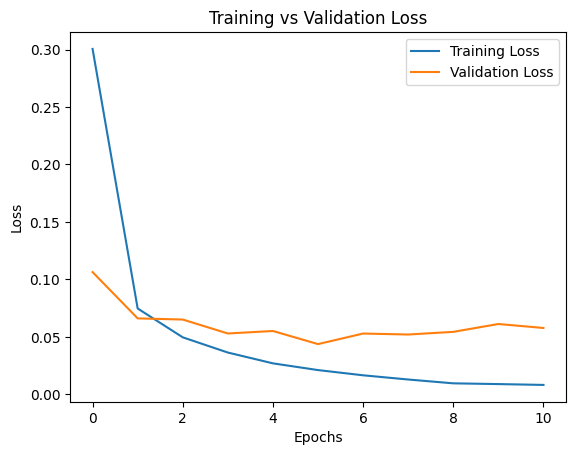

In [ ]:
import matplotlib.pyplot as plt

# Plot Training & Validation Loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

Training vs Validation Accuracy

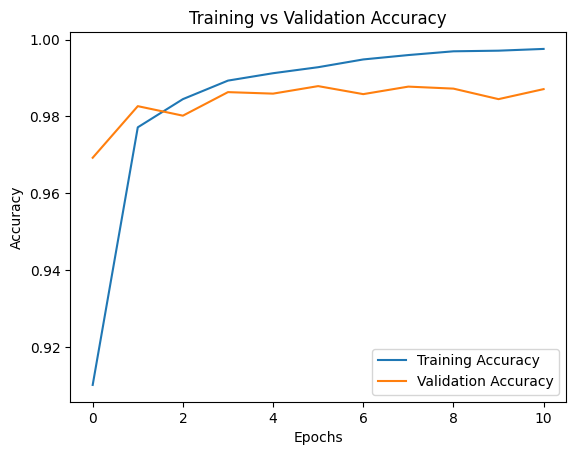

In [ ]:
import matplotlib.pyplot as plt
# Plot Training & Validation Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

Task 3.3: Model Evaluation

1.Evaluate the Model on Test Set

In [ ]:
# Evaluate the trained model on test data
test_loss, test_accuracy = model.evaluate(
    X_test, y_test,
    batch_size=128,
    verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9854 - loss: 0.0394
Test Loss: 0.03132770583033562
Test Accuracy: 0.9886000156402588


2. Generate Classification Report

Make Predictions on Test Data

In [ ]:
import numpy as np

# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.98      0.99      1032
           3       1.00      0.98      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.99      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



3. Create and Visualize Confusion Matrix

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns


3.Create and visualize Confusion Matrix

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[ 975    1    0    0    0    1    1    1    1    0]
 [   0 1131    1    0    0    0    1    1    1    0]
 [   1    2 1016    1    3    0    0    3    6    0]
 [   1    0    3  994    0    6    0    1    5    0]
 [   0    0    0    0  980    0    0    0    0    2]
 [   2    0    0    2    0  884    1    0    1    2]
 [   3    3    0    0    3    1  944    0    4    0]
 [   0    2    6    0    0    0    0 1016    1    3]
 [   3    0    2    0    1    1    0    2  964    1]
 [   3    3    0    1    8    3    0    5    4  982]]


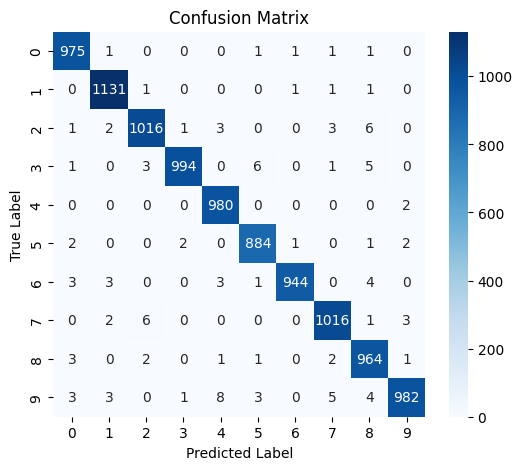

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


4. Calculate Per-Class Accuracy

In [ ]:
import numpy as np

# Confusion matrix already computed as cm
# cm = confusion_matrix(y_test, y_pred)

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(per_class_accuracy):
    print(f"Accuracy for class {i}: {acc:.4f}")


Accuracy for class 0: 0.9949
Accuracy for class 1: 0.9965
Accuracy for class 2: 0.9845
Accuracy for class 3: 0.9842
Accuracy for class 4: 0.9980
Accuracy for class 5: 0.9910
Accuracy for class 6: 0.9854
Accuracy for class 7: 0.9883
Accuracy for class 8: 0.9897
Accuracy for class 9: 0.9732


5. Display Misclassified Examples (At Least 10)

Identify Misclassified Samples

In [ ]:
import numpy as np

# Find indices where prediction is incorrect
misclassified_idx = np.where(y_pred != y_test)[0]

# Select first 10 misclassified samples
misclassified_idx = misclassified_idx[:10]


5.Display Misclassified Images

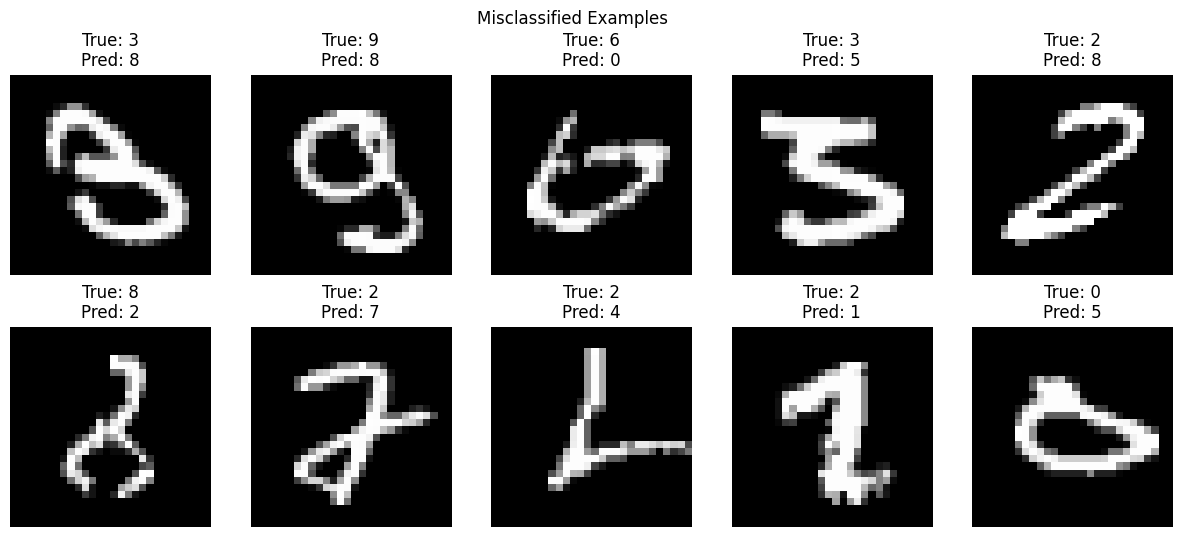

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

for i, idx in enumerate(misclassified_idx):
    plt.subplot(2, 5, i + 1)

    # If images are grayscale
    plt.imshow(X_test[idx].squeeze(), cmap='gray')

    plt.title(f"True: {y_test[idx]}\nPred: {y_pred[idx]}")
    plt.axis('off')

plt.suptitle("Misclassified Examples")
plt.show()
